In [12]:
import torch
from src.data.puzzle_dataset import PuzzleDataset
from src.data.criterion.nonogram import NonogramLoss
from src.models.simple_nn import SimpleNeuralNetwork
from src.models.simple_transformer import SimpleTransformer
from src.training.reward_trainer import RewardTrainer
from src.data.criterion.nonogram import grid_to_row_clues
import matplotlib.pyplot as plt
import os

if "_NOTEBOOK_PARENT_DIR" not in globals():
    _NOTEBOOK_PARENT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(_NOTEBOOK_PARENT_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Database

In [13]:
dataset_name = "nonogram_10x10"

match dataset_name:
    case "nonogram_5x5":
        target_shape = (5, 5)
        location = "processed/nonogram_single_sample_5x5.npy"
        clues = torch.tensor([[[[2,1,0], [2,1,0], [4,0,0], [0,0,0], [1,0,0]], [[1,0,0], [3,1,0], [1,1,0], [2,0,0], [1,1,0]]]], dtype=torch.float32).to(device)
        true_grid = torch.tensor([[0, 1, 1, 0, 1], [1, 1, 0, 1, 0], [0, 1, 1, 1, 1], [0, 0, 0, 0, 0], [0, 1, 0, 0, 0]], dtype=torch.float32).to(device)
    case "nonogram_10x10":
        target_shape = (10, 10)
        location = "processed/nonogram_single_sample_10x10.npy"
        clues = torch.tensor([[[[3,1,1,0,0],[3,3,0,0,0],[2,1,1,1,0],[3,2,0,0,0],[1,0,0,0,0],[6,0,0,0,0],[1,6,0,0,0],[6,0,0,0,0],[3,1,0,0,0],[5,0,0,0,0]],[[3,1,0,0,0],[3,0,0,0,0],[2,0,0,0,0],[2,0,0,0,0],[5,0,0,0,0],[1,5,0,0,0],[1,5,0,0,0],[2,5,0,0,0],[2,1,3,1,0],[3,5,0,0,0]]]],dtype=torch.float32).to(device)
        true_grid = torch.tensor([[1, 1, 1, 0, 0, 0, 1, 0, 1, 0],[1, 1, 1, 0, 0, 0, 0, 1, 1, 1],[1, 1, 0, 1, 0, 0, 0, 1, 0, 1],[0, 0, 0, 1, 1, 1, 0, 0, 1, 1],[0, 0, 0, 0, 1, 0, 0, 0, 0, 0],[0, 0, 0, 0, 1, 1, 1, 1, 1, 1],[1, 0, 0, 0, 1, 1, 1, 1, 1, 1],[0, 0, 0, 0, 1, 1, 1, 1, 1, 1],[0, 0, 0, 0, 0, 1, 1, 1, 0, 1],[0, 0, 0, 0, 0, 1, 1, 1, 1, 1]], dtype=torch.float32).to(device)
    case "nonogram_15x15":
        target_shape = (15, 15)
        location = "processed/nonogram_single_sample_15x15.npy"
        clues = torch.tensor([[[[2, 7, 0, 0, 0, 0, 0, 0],[9, 0, 0, 0, 0, 0, 0, 0],[8, 0, 0, 0, 0, 0, 0, 0],[1, 1, 1, 1, 1, 0, 0, 0],[3, 3, 0, 0, 0, 0, 0, 0],[1, 2, 2, 0, 0, 0, 0, 0],[2, 3, 3, 0, 0, 0, 0, 0],[2, 3, 0, 0, 0, 0, 0, 0],[3, 0, 0, 0, 0, 0, 0, 0],[1, 3, 0, 0, 0, 0, 0, 0],[2, 1, 3, 4, 0, 0, 0, 0],[2, 9, 0, 0, 0, 0, 0, 0],[2, 9, 0, 0, 0, 0, 0, 0],[7, 1, 1, 0, 0, 0, 0, 0],[5, 5, 0, 0, 0, 0, 0, 0]],[[3, 2, 5, 0, 0, 0, 0, 0],[4, 1, 5, 0, 0, 0, 0, 0],[2, 2, 0, 0, 0, 0, 0, 0],[4, 2, 2, 0, 0, 0, 0, 0],[3, 2, 0, 0, 0, 0, 0, 0],[5, 1, 4, 0, 0, 0, 0, 0],[3, 3, 4, 0, 0, 0, 0, 0],[8, 3, 0, 0, 0, 0, 0, 0],[2, 1, 3, 0, 0, 0, 0, 0],[1, 2, 0, 0, 0, 0, 0, 0],[4, 0, 0, 0, 0, 0, 0, 0],[3, 1, 0, 0, 0, 0, 0, 0],[1, 7, 1, 0, 0, 0, 0, 0],[9, 1, 0, 0, 0, 0, 0, 0],[8, 1, 0, 0, 0, 0, 0, 0]]]], dtype=torch.float32).to(device)
        true_grid = torch.tensor([[1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],[0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1],[0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1],[1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1],[1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1],[0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1],[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1],[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1],[1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1],[1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],[1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],[1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0],[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]], dtype=torch.float32)

clues_flat = clues.flatten(start_dim=1)
dataset = PuzzleDataset(
    location, 
    flat=True, 
    target_shape=target_shape)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, 
    [train_size, test_size],
    generator=generator
)

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=8, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, 
    batch_size=8, 
    shuffle=False
)


## Visualisation

In [14]:
def visualise_matrix(matrix):
    inv_matrix = 1 - matrix
    fig, ax = plt.subplots()
    ax.imshow(inv_matrix.cpu().numpy(), cmap='gray')

    # Compute clues
    grid = matrix.reshape(1, *matrix.shape)
    row_clues = grid_to_row_clues(grid, K=3)
    col_clues = grid_to_row_clues(grid.transpose(1, 2), K=3)

    n_rows, n_cols = matrix.shape

    # Row clues on the left
    for r in range(n_rows):
        clue = row_clues[0, r].cpu().tolist()
        clue_str = "\n".join(f"{num:.2f}" for num in clue if num > 0) or "0.00"
        ax.text(-0.6, r, clue_str, va='center', ha='right', fontsize=9)

    # Column clues on the top
    for c in range(n_cols):
        clue = col_clues[0, c].cpu().tolist()
        clue_str = "\n".join(f"{num:.2f}" for num in clue if num > 0) or "0.00"
        ax.text(c, -0.6, clue_str, va='bottom', ha='center', fontsize=9)

    ax.set_xlim(-0.5, n_cols)
    ax.set_ylim(n_rows, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)
    grid_box = plt.Rectangle((-0.5, -0.5), n_cols, n_rows,
                             linewidth=1, edgecolor='black', facecolor='none')
    ax.add_patch(grid_box)

    plt.tight_layout()
    plt.show()

def visualise_guess(model, clues, criterion):
    model.eval()
    with torch.no_grad():
        output = model(clues)
        loss, _, _ = criterion(output, clues)
        visualise_matrix(output.reshape(target_shape))
        print(f"Loss: {loss.item():.4f}")
    model.train()

## Running

In [15]:
def run_training(model_type="nn", total_epochs=5, visualise_every=1):
    torch.manual_seed(42)
    match model_type:
        case "nn":
            # 10x10: 256 hidden size, 9 layers, 0.3 dropout
            model = SimpleNeuralNetwork(
                hidden_size=256,
                num_layers=9,
                dropout=0.3,
                input_size=dataset.input_shape,
                output_size=dataset.target_shape).to(device)
        case "transformer":
            model = SimpleTransformer(
                hidden_size=256,
                num_layers=9,
                dropout=0.3,
                input_size=dataset.input_shape,
                output_size=dataset.target_shape).to(device)
        case _:
            model = None

    criterion = NonogramLoss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    trainer = RewardTrainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        # scheduler=scheduler,
        epochs=visualise_every
    )

    visualise_guess(model, clues_flat, criterion)
    for i in range(total_epochs//visualise_every):
        trainer.train()
        print("="*40)
        print(f"Epoch {i+1}:")
        visualise_guess(model, clues_flat, criterion)
        
    return model

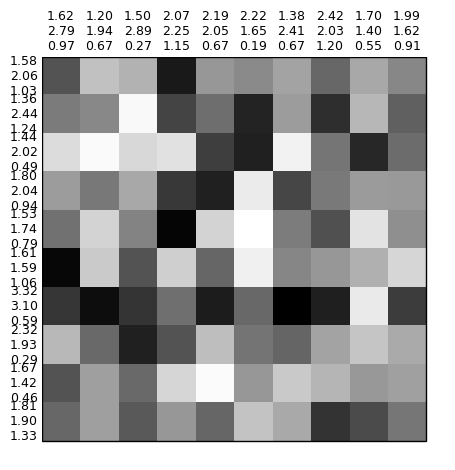

Loss: 3.6151
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.085s
Epoch 00 | Train loss: 1.5724 | Test loss: 0.8815 | Test accuracy: 0.000% | Clue‑match: 0.05%
Load: 0.002s | Transfer: 0.002s | Total: 0.083s
Epoch 01 | Train loss: 0.7473 | Test loss: 0.6788 | Test accuracy: 0.000% | Clue‑match: 0.05%
Load: 0.002s | Transfer: 0.003s | Total: 0.086s
Epoch 02 | Train loss: 0.6224 | Test loss: 0.5963 | Test accuracy: 0.000% | Clue‑match: 0.10%
Load: 0.002s | Transfer: 0.001s | Total: 0.085s
Epoch 03 | Train loss: 0.5920 | Test loss: 0.5962 | Test accuracy: 0.000% | Clue‑match: 0.10%
Load: 0.002s | Transfer: 0.002s | Total: 0.085s
Epoch 04 | Train loss: 0.5800 | Test loss: 0.5732 | Test accuracy: 0.000% | Clue‑match: 0.15%
Load: 0.002s | Transfer: 0.001s | Total: 0.083s
Epoch 05 | Train loss: 0.5576 | Test loss: 0.5563 | Test accuracy: 0.000% | Clue‑match: 0.15%
Load: 0.002s | Transfer: 0.001s | Total: 0.082s
Epoch 06 | Train loss: 0.5460 | Test loss: 0.5464 | Test accurac

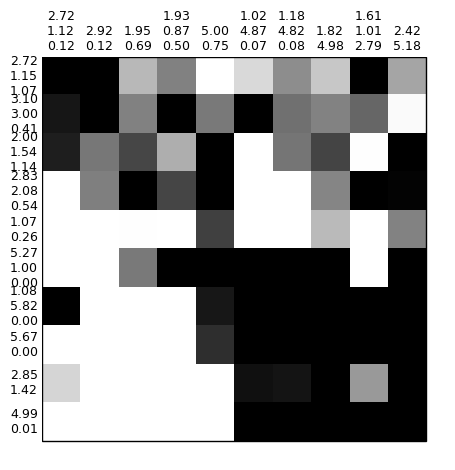

Loss: 0.1185
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.081s
Epoch 00 | Train loss: 0.1007 | Test loss: 0.1186 | Test accuracy: 0.000% | Clue‑match: 0.45%
Load: 0.002s | Transfer: 0.001s | Total: 0.071s
Epoch 01 | Train loss: 0.1008 | Test loss: 0.1205 | Test accuracy: 0.000% | Clue‑match: 0.45%
Load: 0.002s | Transfer: 0.001s | Total: 0.079s
Epoch 02 | Train loss: 0.1007 | Test loss: 0.1175 | Test accuracy: 0.000% | Clue‑match: 0.35%
Load: 0.002s | Transfer: 0.001s | Total: 0.071s
Epoch 03 | Train loss: 0.1006 | Test loss: 0.1174 | Test accuracy: 0.000% | Clue‑match: 0.35%
Load: 0.002s | Transfer: 0.001s | Total: 0.070s
Epoch 04 | Train loss: 0.1007 | Test loss: 0.1167 | Test accuracy: 0.000% | Clue‑match: 0.35%
Load: 0.002s | Transfer: 0.001s | Total: 0.076s
Epoch 05 | Train loss: 0.1007 | Test loss: 0.1181 | Test accuracy: 0.000% | Clue‑match: 0.35%
Load: 0.002s | Transfer: 0.001s | Total: 0.069s
Epoch 06 | Train loss: 0.1007 | Test loss: 0.1169 | Test accurac

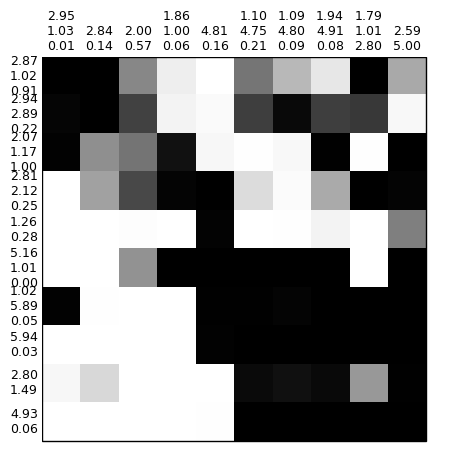

Loss: 0.0916
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.094s
Epoch 00 | Train loss: 0.0777 | Test loss: 0.0875 | Test accuracy: 0.000% | Clue‑match: 0.50%
Load: 0.002s | Transfer: 0.002s | Total: 0.082s
Epoch 01 | Train loss: 0.0755 | Test loss: 0.0864 | Test accuracy: 0.000% | Clue‑match: 0.45%
Load: 0.002s | Transfer: 0.001s | Total: 0.080s
Epoch 02 | Train loss: 0.0748 | Test loss: 0.0868 | Test accuracy: 0.000% | Clue‑match: 0.55%
Load: 0.002s | Transfer: 0.001s | Total: 0.073s
Epoch 03 | Train loss: 0.0742 | Test loss: 0.0884 | Test accuracy: 0.000% | Clue‑match: 0.50%
Load: 0.002s | Transfer: 0.001s | Total: 0.084s
Epoch 04 | Train loss: 0.0724 | Test loss: 0.0808 | Test accuracy: 0.000% | Clue‑match: 0.65%
Load: 0.002s | Transfer: 0.002s | Total: 0.084s
Epoch 05 | Train loss: 0.0700 | Test loss: 0.0847 | Test accuracy: 0.000% | Clue‑match: 0.70%
Load: 0.002s | Transfer: 0.001s | Total: 0.086s
Epoch 06 | Train loss: 0.0657 | Test loss: 0.0695 | Test accurac

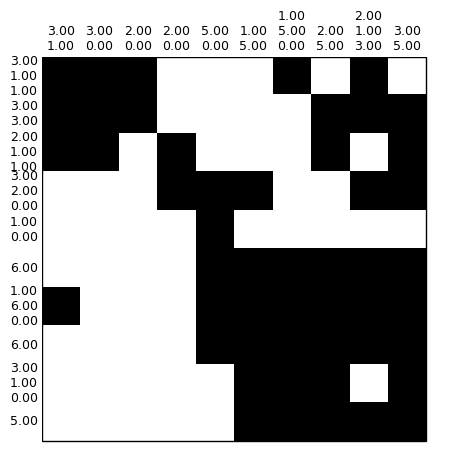

Loss: 0.0000
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.092s
Epoch 00 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.002s | Total: 0.081s
Epoch 01 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.002s | Total: 0.095s
Epoch 02 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.001s | Total: 0.074s
Epoch 03 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.001s | Total: 0.079s
Epoch 04 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.002s | Total: 0.090s
Epoch 05 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.001s | Total: 0.086s
Epoch 06 | Train loss: 0.0000 | Test los

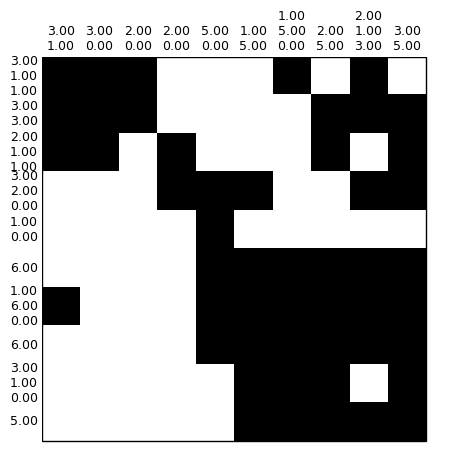

Loss: 0.0000
🚀 Starting training...
Load: 0.003s | Transfer: 0.002s | Total: 0.091s
Epoch 00 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.002s | Total: 0.082s
Epoch 01 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.002s | Total: 0.086s
Epoch 02 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.001s | Total: 0.078s
Epoch 03 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.003s | Transfer: 0.003s | Total: 0.111s
Epoch 04 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.002s | Total: 0.088s
Epoch 05 | Train loss: 0.0000 | Test loss: 0.0000 | Test accuracy: 10000.000% | Clue‑match: 1.00%
Load: 0.002s | Transfer: 0.002s | Total: 0.089s
Epoch 06 | Train loss: 0.0000 | Test los

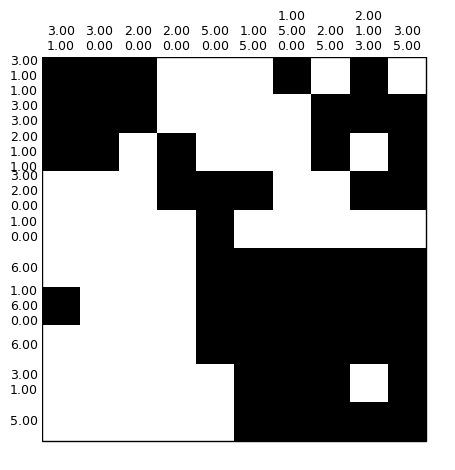

Loss: 0.0000


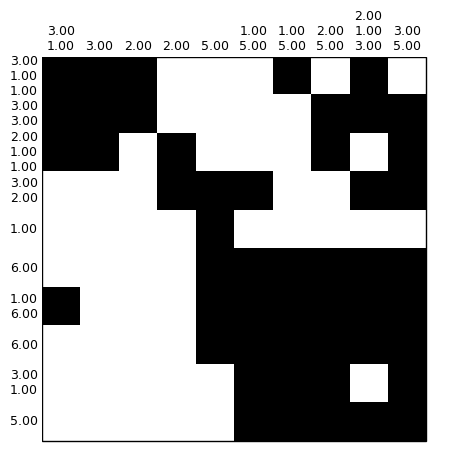

In [16]:
final_model = run_training(model_type="nn", total_epochs=500, visualise_every=100)
visualise_matrix(true_grid)